# Estrous Detection from Ultradian Activity Rhythms (Positive Control)

This notebook provides a **report-style** replication of the key pieces of the Morph2REP-style pipeline on a **positive-control dataset** (female activity, 1-minute resolution, 14 days, 13 mice).

**Goals**
1. QC daily coverage (Morph2REP analog).
2. Compute wavelet-band features, focusing on **ultradian power (1–3 hours)**.
3. Validate the estrus effect using the known estrus timing:
   - Professor-confirmed estrus day: **day==1** (0-based indexing).
   - Paper-like periodic days: **{1,5,9,13}** (0-based).
4. Derive an interpretable **estrus-likeness probability** via a **1D GMM** on `z_U_1_3h`.
5. Demonstrate **label-free 4-day cyclicity** using a **lag-4 permutation test** on `z_U_1_3h`.

> Note: We intentionally do **not** use temperature; this notebook validates estrus signal using **activity only**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score

import pywt
import time

plt.rcParams["figure.dpi"] = 120


## 1) Load data (Fem Act) and reshape to long format

`Fem Act` is a 20160×13 matrix (14 days × 1440 minutes/day) for female mice `f1..f13`.

We construct:
- `minute`: global minute index 0..20159  
- `day`: 0..13  
- `minute_of_day`: 0..1439  
- `act_long`: tidy table with columns `mouse_id, minute, day, minute_of_day, act`


In [2]:
PATH = "Mouse_Data_Student_Copy.xlsx"

act_wide = pd.read_excel(PATH, sheet_name="Fem Act")
assert act_wide.shape == (20160, 13)
assert all(str(c).startswith("f") for c in act_wide.columns)

act = act_wide.copy()
act["minute"] = np.arange(len(act))
act["day"] = act["minute"] // 1440
act["minute_of_day"] = act["minute"] % 1440

act_long = (act.melt(
    id_vars=["minute","day","minute_of_day"],
    value_vars=list(act_wide.columns),
    var_name="mouse_id",
    value_name="act"
).sort_values(["mouse_id","minute"]).reset_index(drop=True))

print("act_long shape:", act_long.shape)
display(act_long.head())


act_long shape: (262080, 5)


,minute,day,minute_of_day,mouse_id,act
0,0,0,0,f1,25.0
1,1,0,1,f1,26.0
2,2,0,2,f1,35.0
3,3,0,3,f1,63.0
4,4,0,4,f1,0.0


## 2) QC: remove low-coverage days (Morph2REP analog)

We use **minutes with activity > 0** per day:

- `minutes_act_gt0 = count(act > 0)` per mouse-day  
- Keep days with `minutes_act_gt0 >= MINUTES_FLOOR` (conservative threshold)

We set:
- `MINUTES_FLOOR = 600`


QC keep rate: 1.0
Days removed per mouse:


mouse_id
f1     0
f10    0
f11    0
f12    0
f13    0
f2     0
f3     0
f4     0
f5     0
f6     0
f7     0
f8     0
f9     0
Name: qc_keep, dtype: int64

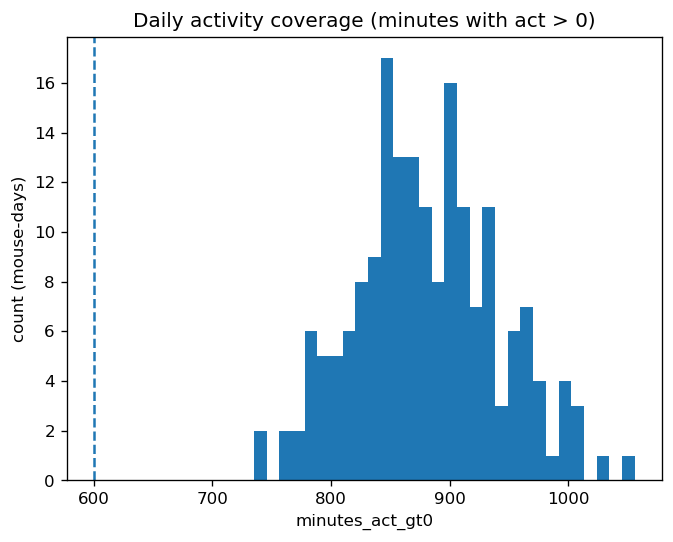

In [3]:
MINUTES_FLOOR = 600
MINUTES_CAP   = 1300

qc_daily = (act_long
    .assign(present=(act_long["act"] > 0).astype(int))
    .groupby(["mouse_id","day"])
    .agg(minutes_act_gt0=("present","sum"),
         act_mean=("act","mean"),
         act_std=("act","std"),
         act_max=("act","max"))
    .reset_index()
)

qc_daily["qc_keep"] = (qc_daily["minutes_act_gt0"] >= MINUTES_FLOOR) & (qc_daily["minutes_act_gt0"] <= MINUTES_CAP)

print("QC keep rate:", float(qc_daily["qc_keep"].mean()))
print("Days removed per mouse:")
display(qc_daily.groupby("mouse_id")["qc_keep"].apply(lambda s: int((~s).sum())).sort_values(ascending=False))

plt.figure()
plt.hist(qc_daily["minutes_act_gt0"], bins=30)
plt.axvline(MINUTES_FLOOR, linestyle="--")
plt.title("Daily activity coverage (minutes with act > 0)")
plt.xlabel("minutes_act_gt0")
plt.ylabel("count (mouse-days)")
plt.show()


## 3) Wavelet-derived features (ultradian + circadian band power)

Per mouse:
- `U_t`: per-minute **ultradian band (1–3h) max wavelet power**
- `C_t`: per-minute **circadian band (23–25h) max wavelet power** (kept for context)

Daily summaries:
- `U_1_3h = mean(U_t within day)`
- `C_23_25h = mean(C_t within day)`
- `log_U_over_C = log(U/C)`

We compute only the two bands to keep runtime reasonable.


In [4]:
DT = 60.0
WAVELET = "cmor1.5-1.0"
fc = pywt.central_frequency(WAVELET)

def scales_for_period_hours(period_hours: float) -> float:
    freq_hz = 1.0 / (period_hours * 3600.0)
    return fc / (freq_hz * DT)

n_scales_per_band = 24
periods_ultr = np.linspace(1.0, 3.0, n_scales_per_band)
periods_circ = np.linspace(23.0, 25.0, n_scales_per_band)

scales_ultr = np.array([scales_for_period_hours(p) for p in periods_ultr], dtype=float)
scales_circ = np.array([scales_for_period_hours(p) for p in periods_circ], dtype=float)

def wavelet_band_series_bandonly(x_14days: np.ndarray):
    x = np.asarray(x_14days, dtype=np.float32)
    coef_u, _ = pywt.cwt(x, scales_ultr, WAVELET, sampling_period=DT)
    coef_c, _ = pywt.cwt(x, scales_circ, WAVELET, sampling_period=DT)
    U_t = (np.abs(coef_u) ** 2).max(axis=0)
    C_t = (np.abs(coef_c) ** 2).max(axis=0)
    return U_t, C_t

t0 = time.time()
rows = []
mice = sorted(act_long["mouse_id"].unique())

for i, mouse_id in enumerate(mice, start=1):
    df_m = act_long[act_long["mouse_id"] == mouse_id].sort_values("minute")
    x = df_m["act"].to_numpy()
    U_t, C_t = wavelet_band_series_bandonly(x)

    for day in range(14):
        lo, hi = day * 1440, (day + 1) * 1440
        rows.append((mouse_id, day, float(np.mean(U_t[lo:hi])), float(np.mean(C_t[lo:hi]))))

    if i % 3 == 0 or i == len(mice):
        print(f"[{i}/{len(mice)}] done {mouse_id}  (elapsed {time.time() - t0:.1f}s)")

feat = pd.DataFrame(rows, columns=["mouse_id", "day", "U_1_3h", "C_23_25h"])
feat["log_U_over_C"] = np.log((feat["U_1_3h"] + 1e-12) / (feat["C_23_25h"] + 1e-12))

feat = feat.merge(qc_daily[["mouse_id","day","minutes_act_gt0","qc_keep"]], on=["mouse_id","day"], how="left")
feat_qc = feat.loc[feat["qc_keep"]].copy()

print("feat_qc shape:", feat_qc.shape)
display(feat_qc.head())


[3/13] done f11  (elapsed 5.5s)
[6/13] done f2  (elapsed 11.0s)
[9/13] done f5  (elapsed 16.5s)
[12/13] done f8  (elapsed 21.9s)
[13/13] done f9  (elapsed 23.8s)
feat_qc shape: (182, 7)


,mouse_id,day,U_1_3h,C_23_25h,log_U_over_C,minutes_act_gt0,qc_keep
0,f1,0,3062.580322,60737.390625,-2.987302,866,True
1,f1,1,1725.448608,75424.320312,-3.777643,901,True
2,f1,2,2192.337402,68390.890625,-3.440271,848,True
3,f1,3,1814.376343,68450.179688,-3.630364,881,True
4,f1,4,2125.419189,80869.085938,-3.638863,907,True


## 4) Robust z-scoring per mouse

`z = (x - median) / (1.4826 * MAD)`


In [5]:
def robust_z(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-12
    return (x - med) / (1.4826 * mad)

for col in ["U_1_3h", "C_23_25h", "log_U_over_C"]:
    feat_qc[f"z_{col}"] = feat_qc.groupby("mouse_id")[col].transform(robust_z)

display(feat_qc[["mouse_id","day","minutes_act_gt0","z_U_1_3h","z_C_23_25h","z_log_U_over_C"]].head())


,mouse_id,day,minutes_act_gt0,z_U_1_3h,z_C_23_25h,z_log_U_over_C
0,f1,0,866,1.362957,-1.385400,1.606708
1,f1,1,901,-0.653695,0.147376,-0.449503
2,f1,2,848,0.050463,-0.586656,0.428228
3,f1,3,881,-0.519575,-0.580468,-0.066332
4,f1,4,907,-0.050463,0.715610,-0.088442


### Figure: heatmap of ultradian power across days


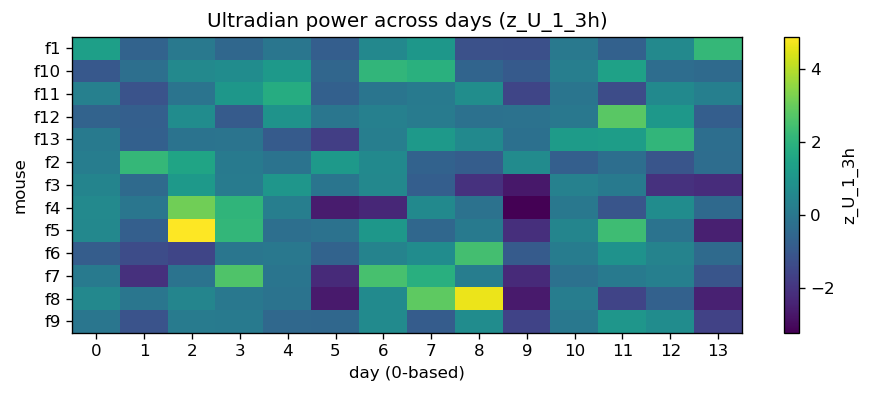

In [6]:
pivot = feat_qc.pivot(index="mouse_id", columns="day", values="z_U_1_3h").sort_index()

plt.figure(figsize=(9, 3.2))
im = plt.imshow(pivot.values, aspect="auto")
plt.title("Ultradian power across days (z_U_1_3h)")
plt.xlabel("day (0-based)")
plt.ylabel("mouse")
plt.colorbar(im, label="z_U_1_3h")
plt.xticks(range(pivot.shape[1]), list(pivot.columns))
plt.yticks(range(pivot.shape[0]), list(pivot.index))
plt.show()


## 5) Estrus validation using known estrus day(s)



 is_estrus_A n_mice: 13
count    13.000000
mean     -0.620011
std       1.061034
min      -2.234430
25%      -1.220462
50%      -0.977365
75%       0.019070
max       2.143553
Name: diff_estrus_minus_non, dtype: float64
Wilcoxon p (estrus lower): 0.0286865234375

 is_estrus_B n_mice: 13
count    13.000000
mean     -1.314456
std       1.011183
min      -2.649105
25%      -1.959782
50%      -1.220257
75%      -1.080632
max       1.039445
Name: diff_estrus_minus_non, dtype: float64
Wilcoxon p (estrus lower): 0.0006103515625


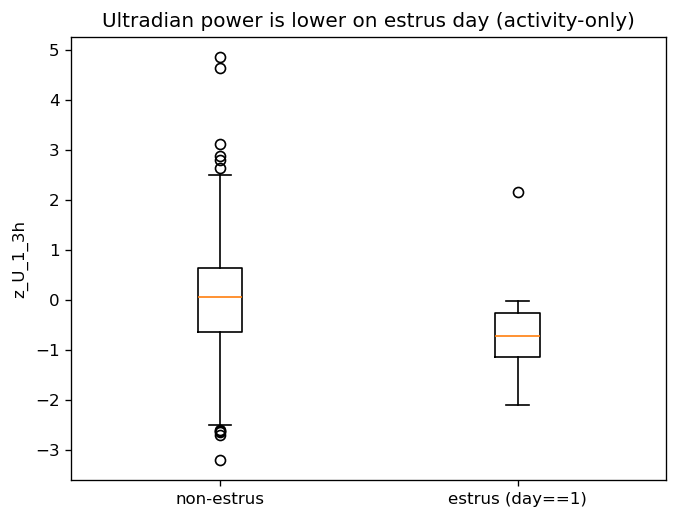

In [7]:
df = feat_qc.copy()
df["is_estrus_A"] = (df["day"] == 1)
df["is_estrus_B"] = df["day"].isin([1,5,9,13])

def within_mouse_effect(df, estrus_col, value_col="z_U_1_3h"):
    rows = []
    for mid, g in df.groupby("mouse_id"):
        e = g.loc[g[estrus_col], value_col]
        n = g.loc[~g[estrus_col], value_col]
        if len(e) == 0 or len(n) == 0:
            continue
        rows.append((mid, float(e.mean()), float(n.mean()), float(e.mean() - n.mean())))
    return pd.DataFrame(rows, columns=["mouse_id","estrus_mean","non_mean","diff_estrus_minus_non"])

for label in ["is_estrus_A", "is_estrus_B"]:
    eff = within_mouse_effect(df, label, "z_U_1_3h")
    stat, p = wilcoxon(eff["diff_estrus_minus_non"], alternative="less")
    print("\n", label, "n_mice:", len(eff))
    print(eff["diff_estrus_minus_non"].describe())
    print("Wilcoxon p (estrus lower):", p)

plt.figure()
vals0 = df.loc[~df["is_estrus_A"], "z_U_1_3h"].to_numpy()
vals1 = df.loc[df["is_estrus_A"], "z_U_1_3h"].to_numpy()
plt.boxplot([vals0, vals1], labels=["non-estrus", "estrus (day==1)"])
plt.title("Ultradian power is lower on estrus day (activity-only)")
plt.ylabel("z_U_1_3h")
plt.show()


## 6) 1D GMM estrus-likeness score: `p_lowU_1d`


1D GMM means: [-0.1914797   0.65686503] weights: [0.74900916 0.25099084] lowU_comp_1d: 0
count    182.000000
mean       0.749463
std        0.188144
min        0.000259
25%        0.739435
50%        0.832196
75%        0.852707
max        0.861453
Name: p_lowU_1d, dtype: float64
AUC p_lowU_1d vs day==1: 0.700045516613564
AUC p_lowU_1d vs {1,5,9,13}: 0.6116863905325445


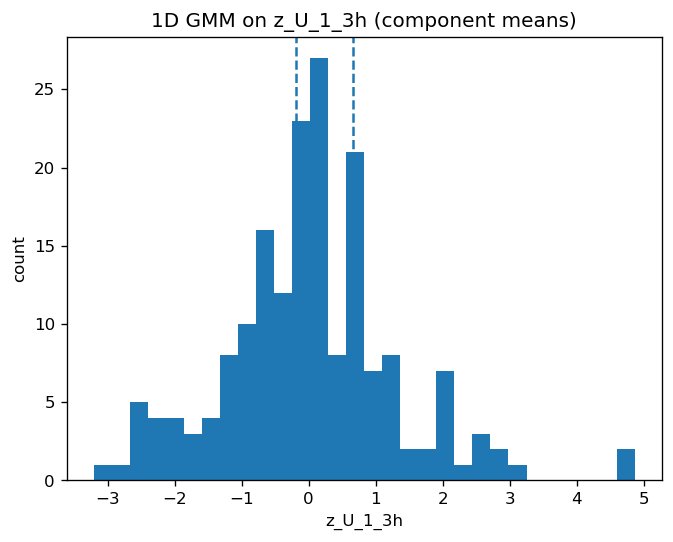

In [8]:
X1 = feat_qc[["z_U_1_3h"]].to_numpy()
gmm1 = GaussianMixture(n_components=2, random_state=0).fit(X1)

post1 = gmm1.predict_proba(X1)
means1 = gmm1.means_.flatten()
weights1 = gmm1.weights_.flatten()

lowU_comp_1d = int(np.argmin(means1))
feat_qc["p_lowU_1d"] = post1[:, lowU_comp_1d]

print("1D GMM means:", means1, "weights:", weights1, "lowU_comp_1d:", lowU_comp_1d)
print(feat_qc["p_lowU_1d"].describe())

yA = (feat_qc["day"] == 1).astype(int)
yB = feat_qc["day"].isin([1,5,9,13]).astype(int)
print("AUC p_lowU_1d vs day==1:", roc_auc_score(yA, feat_qc["p_lowU_1d"]))
print("AUC p_lowU_1d vs {1,5,9,13}:", roc_auc_score(yB, feat_qc["p_lowU_1d"]))

plt.figure()
plt.hist(feat_qc["z_U_1_3h"], bins=30)
for m in sorted(means1):
    plt.axvline(m, linestyle="--")
plt.title("1D GMM on z_U_1_3h (component means)")
plt.xlabel("z_U_1_3h")
plt.ylabel("count")
plt.show()


## 7) Label-free 4-day cyclicity detection (Permutation test)

We test whether `z_U_1_3h` shows lag-4 autocorrelation beyond chance.


Observed lag-4 cyclicity (z_U_1_3h): 0.3305468292248488
Monte Carlo p-value: 0.0001999600079984003


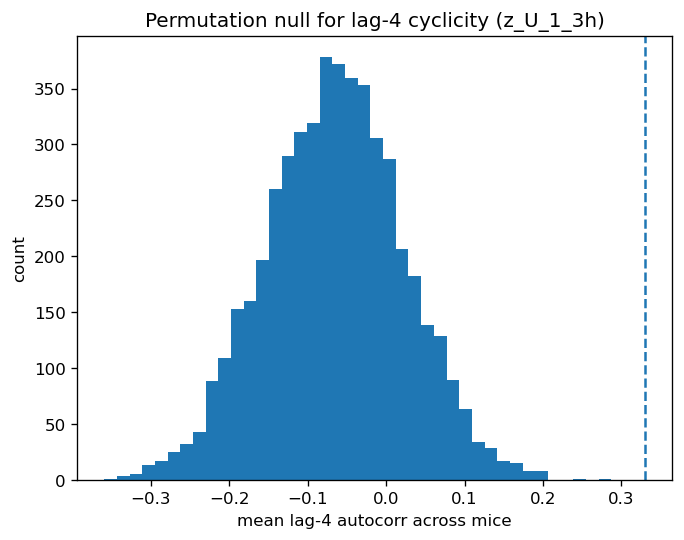

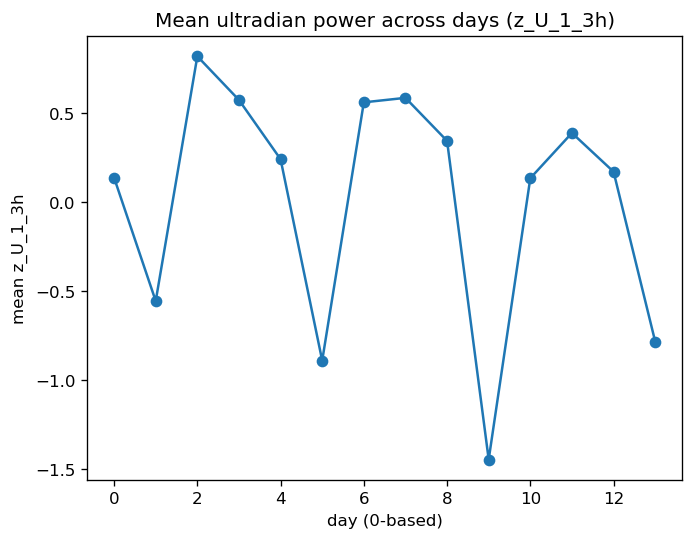

In [9]:
def lag4_autocorr_per_mouse(values_by_day: pd.Series):
    y = values_by_day.sort_index().to_numpy(dtype=float)
    if len(y) <= 4:
        return np.nan
    y0, y4 = y[:-4], y[4:]
    if np.std(y0) < 1e-12 or np.std(y4) < 1e-12:
        return np.nan
    return float(np.corrcoef(y0, y4)[0,1])

def cyclicity_score(df, value_col="z_U_1_3h"):
    per = []
    for mid, g in df.groupby("mouse_id"):
        s = g.set_index("day")[value_col]
        per.append(lag4_autocorr_per_mouse(s))
    per = np.array(per, dtype=float)
    per = per[np.isfinite(per)]
    return float(np.mean(per)) if len(per) else np.nan

def monte_carlo_null(df, value_col="z_U_1_3h", n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        dfp = df.copy()
        dfp[value_col] = dfp.groupby("mouse_id")[value_col].transform(lambda x: rng.permutation(x.to_numpy()))
        null.append(cyclicity_score(dfp, value_col=value_col))
    null = np.array(null, dtype=float)
    return null[np.isfinite(null)]

obs = cyclicity_score(feat_qc, value_col="z_U_1_3h")
null = monte_carlo_null(feat_qc, value_col="z_U_1_3h", n_perm=5000, seed=0)
p_mc = (np.sum(null >= obs) + 1) / (len(null) + 1)

print("Observed lag-4 cyclicity (z_U_1_3h):", obs)
print("Monte Carlo p-value:", p_mc)

plt.figure()
plt.hist(null, bins=40)
plt.axvline(obs, linestyle="--")
plt.title("Permutation null for lag-4 cyclicity (z_U_1_3h)")
plt.xlabel("mean lag-4 autocorr across mice")
plt.ylabel("count")
plt.show()

mean_day = feat_qc.groupby("day")["z_U_1_3h"].mean().reindex(range(14))
plt.figure()
plt.plot(mean_day.index, mean_day.values, marker="o")
plt.title("Mean ultradian power across days (z_U_1_3h)")
plt.xlabel("day (0-based)")
plt.ylabel("mean z_U_1_3h")
plt.show()


## 8) Bootstrap uncertainty (optional reporting)

Cluster bootstrap over mice:
- AUC CI for `p_lowU_1d`
- CI for estrus effect size on `z_U_1_3h`


In [10]:
rng = np.random.default_rng(0)

def bootstrap_auc(feat_qc, label_days, score_col="p_lowU_1d", B=5000):
    mice = np.array(sorted(feat_qc["mouse_id"].unique()))
    aucs = []
    for _ in range(B):
        samp = rng.choice(mice, size=len(mice), replace=True)
        dfb = feat_qc[feat_qc["mouse_id"].isin(samp)].copy()
        y = dfb["day"].isin(label_days).astype(int).to_numpy()
        s = dfb[score_col].to_numpy()
        if y.min() == y.max():
            continue
        aucs.append(roc_auc_score(y, s))
    aucs = np.array(aucs, dtype=float)
    return float(np.mean(aucs)), np.quantile(aucs, [0.025, 0.975])

def estrus_effect_per_mouse(feat_qc, label_days, value_col="z_U_1_3h"):
    diffs = []
    for mid, g in feat_qc.groupby("mouse_id"):
        e = g[g["day"].isin(label_days)][value_col]
        n = g[~g["day"].isin(label_days)][value_col]
        if len(e)==0 or len(n)==0:
            continue
        diffs.append(float(e.mean() - n.mean()))
    return np.array(diffs, dtype=float)

mean_auc_A, ci_A = bootstrap_auc(feat_qc, label_days=[1], score_col="p_lowU_1d")
mean_auc_B, ci_B = bootstrap_auc(feat_qc, label_days=[1,5,9,13], score_col="p_lowU_1d")

print("Bootstrap AUC (day==1):", mean_auc_A, "95% CI:", ci_A)
print("Bootstrap AUC (1,5,9,13):", mean_auc_B, "95% CI:", ci_B)

diffs = estrus_effect_per_mouse(feat_qc, [1], value_col="z_U_1_3h")
boot = [float(np.mean(rng.choice(diffs, size=len(diffs), replace=True))) for _ in range(5000)]
ci_diff = np.quantile(boot, [0.025, 0.975])

print("Mean diff (estrus - non), day==1:", float(diffs.mean()))
print("Bootstrap 95% CI:", ci_diff)


Bootstrap AUC (day==1): 0.7001033627660218 95% CI: [0.59183189 0.82572177]
Bootstrap AUC (1,5,9,13): 0.6121198292681505 95% CI: [0.52160494 0.70347331]
Mean diff (estrus - non), day==1: -0.6200114039156704
Bootstrap 95% CI: [-1.11363446 -0.00725006]


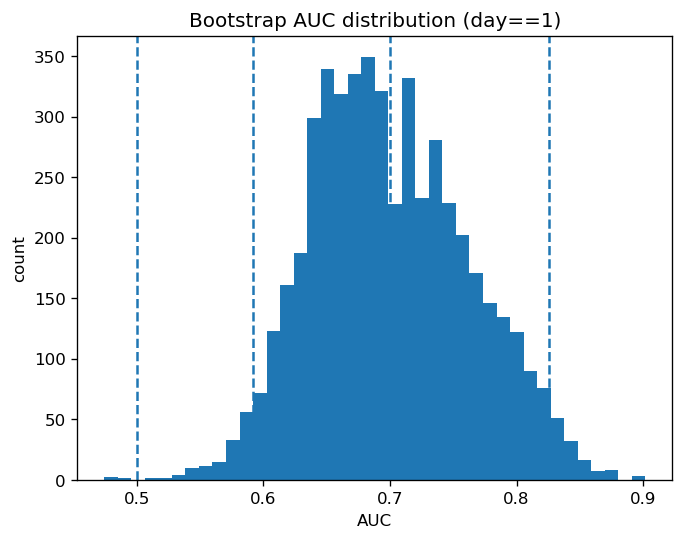

mean: 0.7001033627660218 95% CI: [0.59183189 0.82572177]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(0)

def bootstrap_auc_dist(feat_qc, label_days, score_col="p_lowU_1d", B=5000):
    mice = np.array(sorted(feat_qc["mouse_id"].unique()))
    aucs = []
    for _ in range(B):
        samp = rng.choice(mice, size=len(mice), replace=True)
        dfb = feat_qc[feat_qc["mouse_id"].isin(samp)].copy()
        y = dfb["day"].isin(label_days).astype(int).to_numpy()
        s = dfb[score_col].to_numpy()
        if y.min() == y.max():
            continue
        aucs.append(roc_auc_score(y, s))
    return np.array(aucs)

aucs = bootstrap_auc_dist(feat_qc, [1], score_col="p_lowU_1d", B=5000)
ci = np.quantile(aucs, [0.025, 0.975])
mean_auc = aucs.mean()

plt.figure()
plt.hist(aucs, bins=40)
plt.axvline(0.5, linestyle="--")
plt.axvline(mean_auc, linestyle="--")
plt.axvline(ci[0], linestyle="--")
plt.axvline(ci[1], linestyle="--")
plt.title("Bootstrap AUC distribution (day==1)")
plt.xlabel("AUC")
plt.ylabel("count")
plt.show()

print("mean:", mean_auc, "95% CI:", ci)

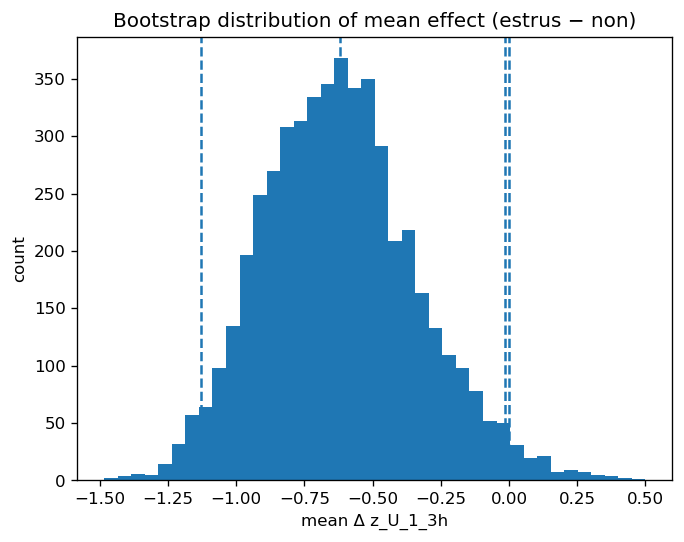

mean: -0.6196453514110132 95% CI: [-1.13037566 -0.01623688]


In [12]:
def estrus_effect_per_mouse(feat_qc, label_days, value_col="z_U_1_3h"):
    diffs = []
    for mid, g in feat_qc.groupby("mouse_id"):
        e = g[g["day"].isin(label_days)][value_col]
        n = g[~g["day"].isin(label_days)][value_col]
        if len(e)==0 or len(n)==0:
            continue
        diffs.append(float(e.mean() - n.mean()))
    return np.array(diffs)

diffs = estrus_effect_per_mouse(feat_qc, [1], value_col="z_U_1_3h")

boot = [np.mean(rng.choice(diffs, size=len(diffs), replace=True)) for _ in range(5000)]
boot = np.array(boot)
ci = np.quantile(boot, [0.025, 0.975])

plt.figure()
plt.hist(boot, bins=40)
plt.axvline(0, linestyle="--")
plt.axvline(boot.mean(), linestyle="--")
plt.axvline(ci[0], linestyle="--")
plt.axvline(ci[1], linestyle="--")
plt.title("Bootstrap distribution of mean effect (estrus − non)")
plt.xlabel("mean Δ z_U_1_3h")
plt.ylabel("count")
plt.show()

print("mean:", boot.mean(), "95% CI:", ci)

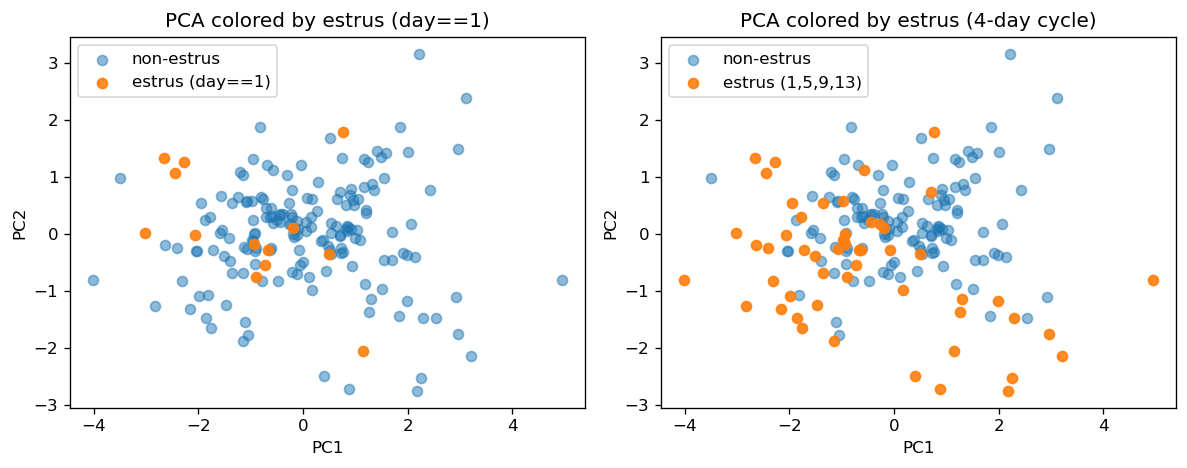

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

dfp = feat_qc.copy()
dfp["is_estrus_A"] = (dfp["day"] == 1)
dfp["is_estrus_B"] = dfp["day"].isin([1,5,9,13])

X = dfp[["z_U_1_3h", "z_C_23_25h", "z_log_U_over_C"]].to_numpy()
X = StandardScaler().fit_transform(X)

pcs = PCA(n_components=2, random_state=0).fit_transform(X)
dfp["PC1"], dfp["PC2"] = pcs[:,0], pcs[:,1]

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

# A: day==1 only
axs[0].scatter(dfp.loc[~dfp["is_estrus_A"], "PC1"], dfp.loc[~dfp["is_estrus_A"], "PC2"], alpha=0.5, label="non-estrus")
axs[0].scatter(dfp.loc[dfp["is_estrus_A"], "PC1"], dfp.loc[dfp["is_estrus_A"], "PC2"], alpha=0.9, label="estrus (day==1)")
axs[0].set_title("PCA colored by estrus (day==1)")
axs[0].set_xlabel("PC1"); axs[0].set_ylabel("PC2")
axs[0].legend()

# B: {1,5,9,13}
axs[1].scatter(dfp.loc[~dfp["is_estrus_B"], "PC1"], dfp.loc[~dfp["is_estrus_B"], "PC2"], alpha=0.5, label="non-estrus")
axs[1].scatter(dfp.loc[dfp["is_estrus_B"], "PC1"], dfp.loc[dfp["is_estrus_B"], "PC2"], alpha=0.9, label="estrus (1,5,9,13)")
axs[1].set_title("PCA colored by estrus (4-day cycle)")
axs[1].set_xlabel("PC1"); axs[1].set_ylabel("PC2")
axs[1].legend()

plt.tight_layout()
plt.show()

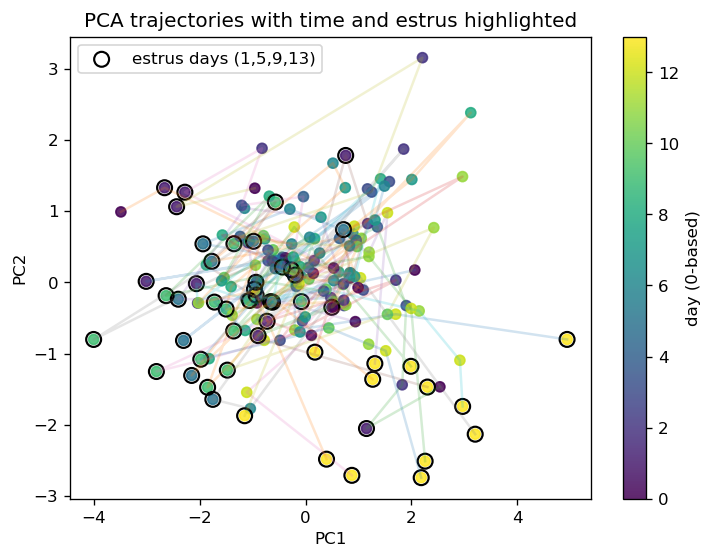

In [17]:
import numpy as np
import matplotlib.pyplot as plt

dfp = dfp.sort_values(["mouse_id","day"]).copy()
estrus_days = {1,5,9,13}

plt.figure(figsize=(7,5), dpi=120)

# faint trajectory lines per mouse
for mid, g in dfp.groupby("mouse_id"):
    plt.plot(g["PC1"], g["PC2"], alpha=0.2)

# scatter points colored by day (gives temporal direction)
sc = plt.scatter(dfp["PC1"], dfp["PC2"], c=dfp["day"], alpha=0.85)
plt.colorbar(sc, label="day (0-based)")

# highlight estrus days with circles (outline)
estr = dfp[dfp["day"].isin(estrus_days)]
plt.scatter(estr["PC1"], estr["PC2"], facecolors="none", edgecolors="black", s=80, linewidths=1.3, label="estrus days (1,5,9,13)")

plt.title("PCA trajectories with time and estrus highlighted")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.show()

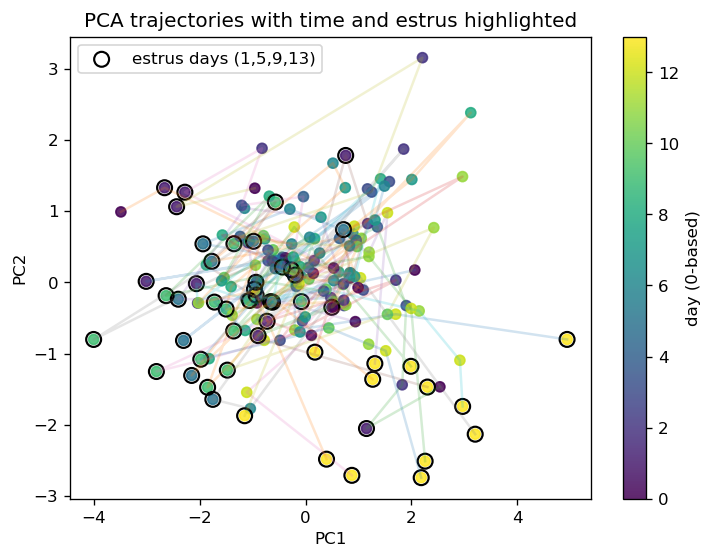

In [18]:
import numpy as np
import matplotlib.pyplot as plt

dfp = dfp.sort_values(["mouse_id","day"]).copy()
estrus_days = {1,5,9,13}

plt.figure(figsize=(7,5), dpi=120)

# faint trajectory lines per mouse
for mid, g in dfp.groupby("mouse_id"):
    plt.plot(g["PC1"], g["PC2"], alpha=0.2)

# scatter points colored by day (gives temporal direction)
sc = plt.scatter(dfp["PC1"], dfp["PC2"], c=dfp["day"], alpha=0.85)
plt.colorbar(sc, label="day (0-based)")

# highlight estrus days with circles (outline)
estr = dfp[dfp["day"].isin(estrus_days)]
plt.scatter(estr["PC1"], estr["PC2"], facecolors="none", edgecolors="black", s=80, linewidths=1.3, label="estrus days (1,5,9,13)")

plt.title("PCA trajectories with time and estrus highlighted")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.show()

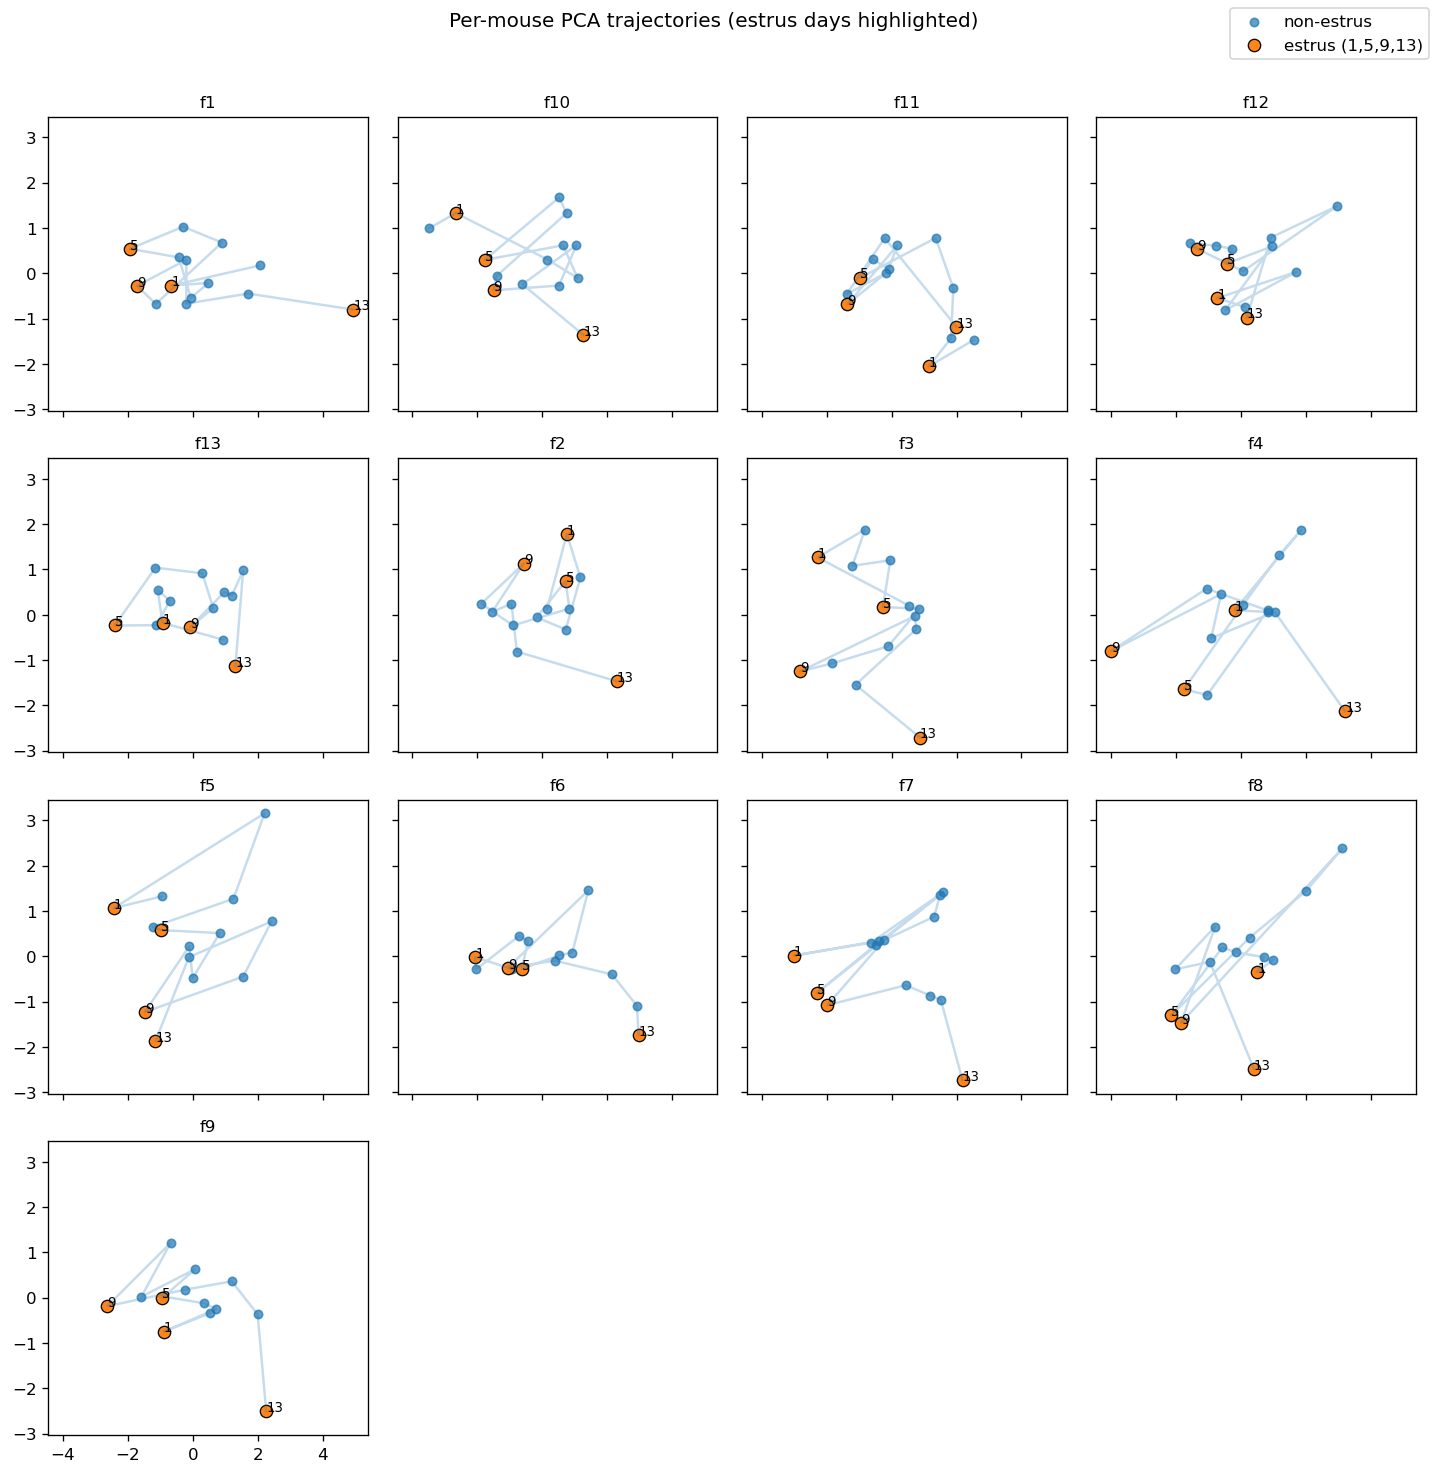

In [23]:
import numpy as np
import matplotlib.pyplot as plt

estrus_days = {1,5,9,13}   # 4-day cycle label

mice = sorted(dfp["mouse_id"].unique())
n = len(mice)
cols = 4
rows = int(np.ceil(n/cols))

fig, axs = plt.subplots(rows, cols, figsize=(12, 3*rows), dpi=120, sharex=True, sharey=True)
axs = axs.flatten()

for ax, mid in zip(axs, mice):
    g = dfp[dfp["mouse_id"]==mid].sort_values("day").copy()
    g["is_estrus"] = g["day"].isin(estrus_days)

    # trajectory line (faint)
    ax.plot(g["PC1"], g["PC2"], alpha=0.25)

    # non-estrus points
    ax.scatter(g.loc[~g["is_estrus"], "PC1"], g.loc[~g["is_estrus"], "PC2"],
               alpha=0.7, s=25, label="non-estrus" if mid==mice[0] else None)

    # estrus points highlighted
    ax.scatter(g.loc[g["is_estrus"], "PC1"], g.loc[g["is_estrus"], "PC2"],
               alpha=0.95, s=55, edgecolors="black", linewidths=0.8,
               label="estrus (1,5,9,13)" if mid==mice[0] else None)

    ax.set_title(mid, fontsize=10)

    # optional: label estrus days
    for _, r in g[g["is_estrus"]].iterrows():
        ax.text(r["PC1"], r["PC2"], str(int(r["day"])), fontsize=8)

for ax in axs[n:]:
    ax.axis("off")

fig.suptitle("Per-mouse PCA trajectories (estrus days highlighted)", y=1.02)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_874/382224798.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


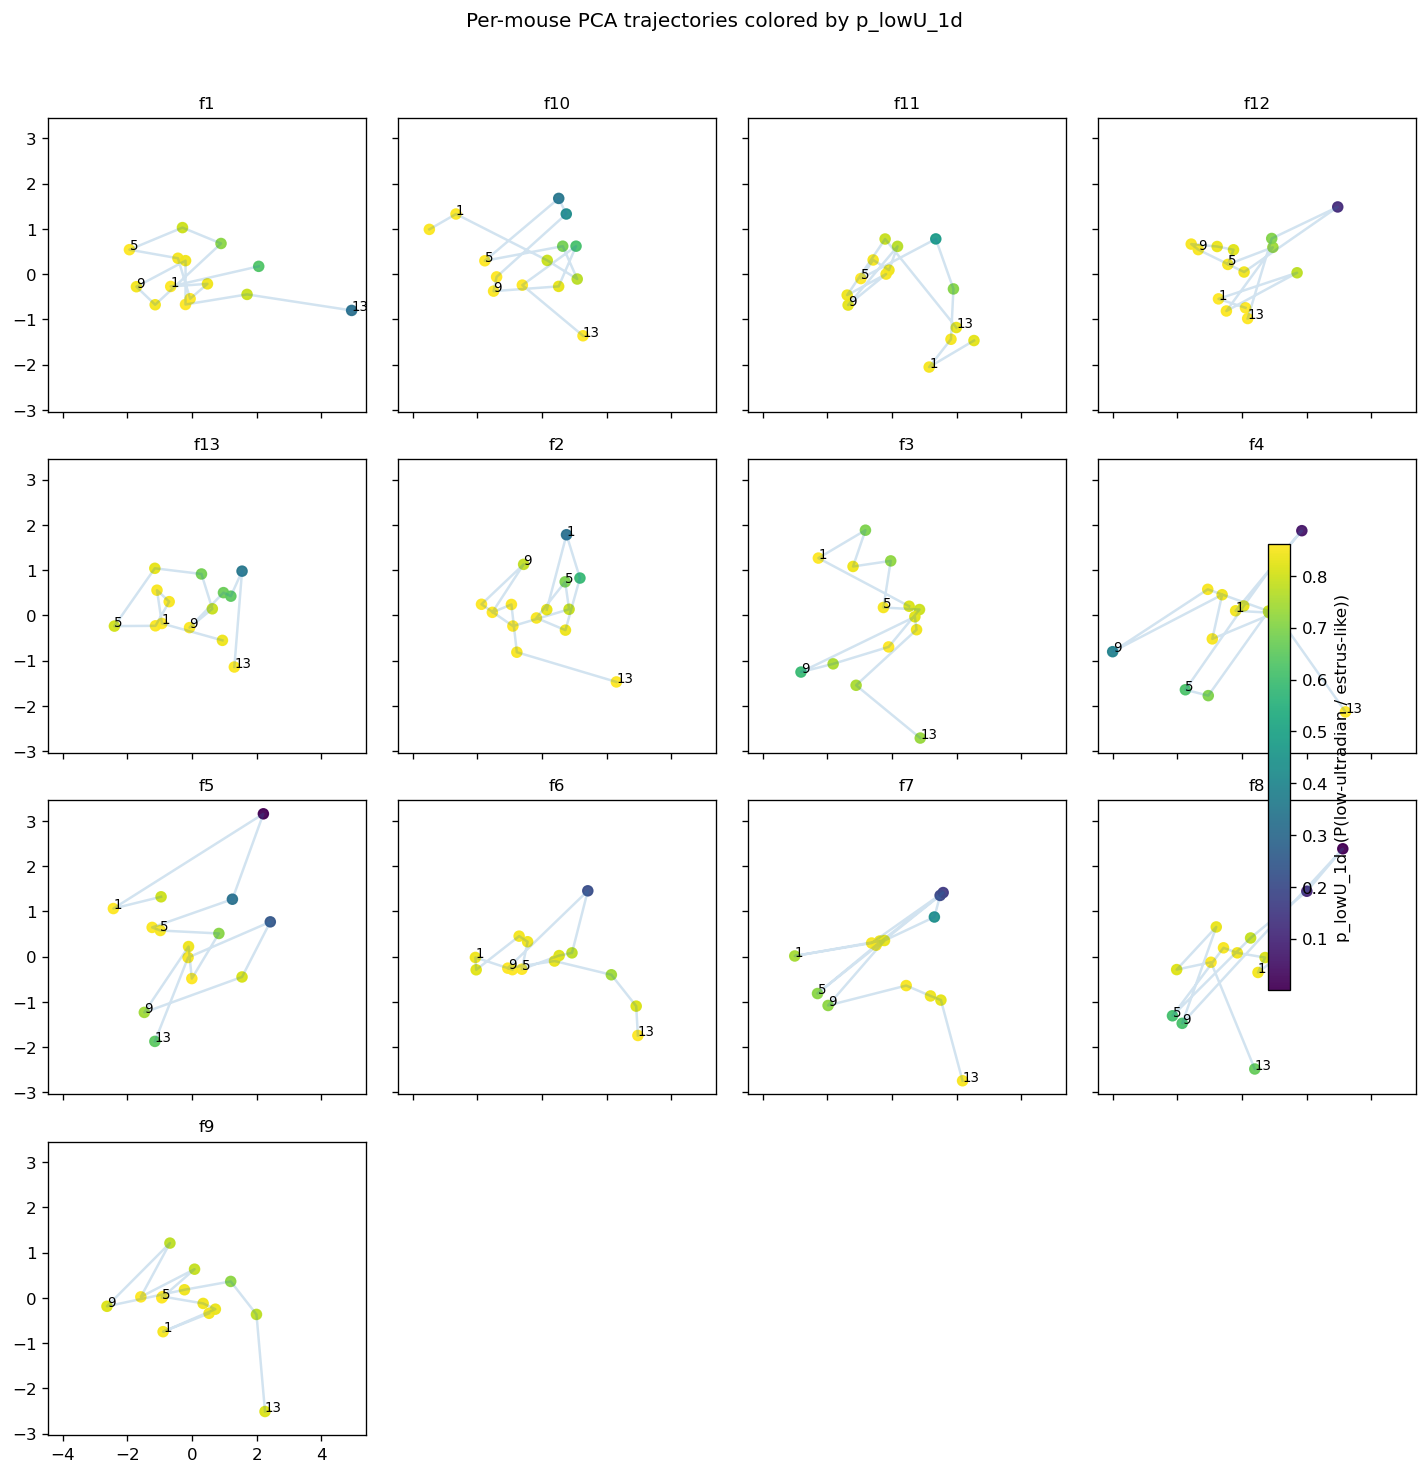

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# sanity check: make sure column exists
assert "p_lowU_1d" in dfp.columns, "dfp must contain p_lowU_1d (merge it in if needed)."

mice = sorted(dfp["mouse_id"].unique())
n = len(mice)
cols = 4
rows = int(np.ceil(n/cols))

fig, axs = plt.subplots(rows, cols, figsize=(12, 3*rows), dpi=120, sharex=True, sharey=True)
axs = axs.flatten()

# consistent color scale across all panels
vmin = float(dfp["p_lowU_1d"].min())
vmax = float(dfp["p_lowU_1d"].max())

for ax, mid in zip(axs, mice):
    g = dfp[dfp["mouse_id"] == mid].sort_values("day")

    # faint trajectory line
    ax.plot(g["PC1"], g["PC2"], alpha=0.20)

    # points colored by probability
    sc = ax.scatter(
        g["PC1"], g["PC2"],
        c=g["p_lowU_1d"],
        vmin=vmin, vmax=vmax,
        s=35, alpha=0.95
    )

    # label days (optional: label just estrus-cycle anchor days or all days)
    for _, r in g.iterrows():
        if r["day"] in [1,5,9,13]:
            ax.text(r["PC1"], r["PC2"], str(int(r["day"])), fontsize=8)

    ax.set_title(mid, fontsize=10)

for ax in axs[n:]:
    ax.axis("off")

fig.suptitle("Per-mouse PCA trajectories colored by p_lowU_1d", y=1.02)

# one shared colorbar
cbar = fig.colorbar(sc, ax=axs[:n], fraction=0.02, pad=0.02)
cbar.set_label("p_lowU_1d  (P(low-ultradian / estrus-like))")

plt.tight_layout()
plt.show()

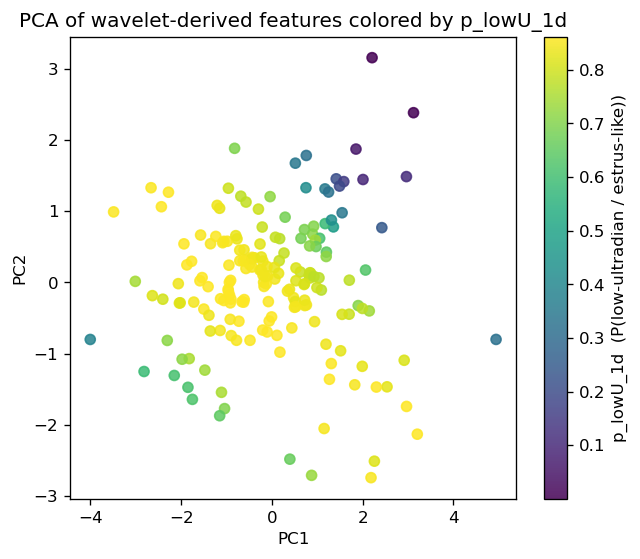

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5), dpi=120)
sc = plt.scatter(dfp["PC1"], dfp["PC2"], c=dfp["p_lowU_1d"], alpha=0.85)
plt.colorbar(sc, label="p_lowU_1d  (P(low-ultradian / estrus-like))")
plt.title("PCA of wavelet-derived features colored by p_lowU_1d")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

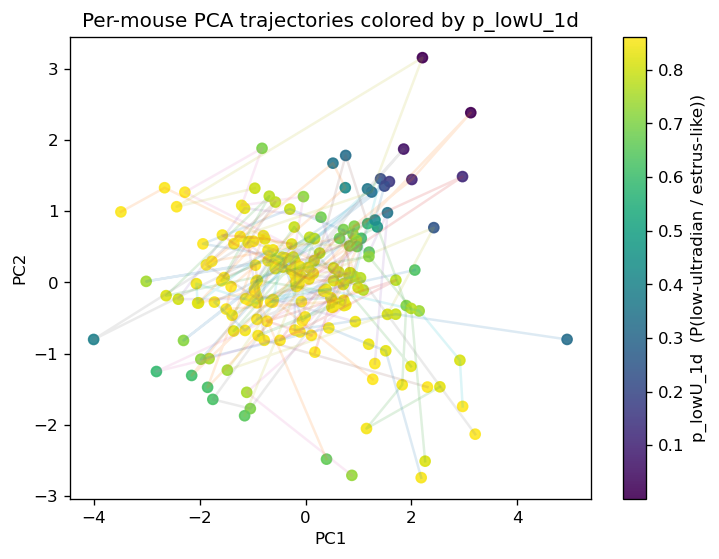

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5), dpi=120)

# draw faint lines per mouse
for mid, g in dfp.sort_values("day").groupby("mouse_id"):
    plt.plot(g["PC1"], g["PC2"], alpha=0.15)

# points colored by p_lowU_1d
sc = plt.scatter(dfp["PC1"], dfp["PC2"], c=dfp["p_lowU_1d"], alpha=0.9)
plt.colorbar(sc, label="p_lowU_1d  (P(low-ultradian / estrus-like))")

plt.title("Per-mouse PCA trajectories colored by p_lowU_1d")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

## 9) Summary

**Key findings (activity-only):**
- Ultradian wavelet power (`z_U_1_3h`) is **lower on estrus days**.
- A **1D GMM** on `z_U_1_3h` yields a probabilistic estrus-likeness score `p_lowU_1d` with AUC > 0.5 against known estrus timing.
- `z_U_1_3h` shows **label-free 4-day structure** via a lag-4 permutation test.

**Port to Morph2REP**
- Use `z_U_1_3h` for periodicity detection (most sensitive).
- Use `p_lowU_1d` as the primary interpretable estrus-likeness probability for downstream analyses.


In [25]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from sklearn.metrics import roc_auc_score

# -----------------------------
# Helpers
# -----------------------------
def per_mouse_diff(df, label_days, value_col="z_U_1_3h"):
    """Compute within-mouse mean(estrus) - mean(non) diffs."""
    diffs = []
    for mid, g in df.groupby("mouse_id"):
        e = g[g["day"].isin(label_days)][value_col]
        n = g[~g["day"].isin(label_days)][value_col]
        if len(e) == 0 or len(n) == 0:
            continue
        diffs.append(float(e.mean() - n.mean()))
    return np.array(diffs, dtype=float)

def bootstrap_auc(feat_qc, label_days, score_col="p_lowU_1d", B=5000, seed=0):
    rng = np.random.default_rng(seed)
    mice = np.array(sorted(feat_qc["mouse_id"].unique()))
    aucs = []
    for _ in range(B):
        samp = rng.choice(mice, size=len(mice), replace=True)
        dfb = feat_qc[feat_qc["mouse_id"].isin(samp)]
        y = dfb["day"].isin(label_days).astype(int).to_numpy()
        s = dfb[score_col].to_numpy()
        if y.min() == y.max():
            continue
        aucs.append(roc_auc_score(y, s))
    aucs = np.array(aucs, dtype=float)
    return float(aucs.mean()), np.quantile(aucs, [0.025, 0.975])

def bootstrap_mean_ci(x, B=5000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    boots = [np.mean(rng.choice(x, size=len(x), replace=True)) for _ in range(B)]
    boots = np.array(boots, dtype=float)
    return float(boots.mean()), np.quantile(boots, [0.025, 0.975])

# assumes you already defined these earlier in notebook:
# cyclicity_score(df, value_col)
# monte_carlo_null(df, value_col, n_perm, seed)

# -----------------------------
# Safety checks
# -----------------------------
required_cols = ["mouse_id","day","minutes_act_gt0","z_U_1_3h","p_lowU_1d"]
missing = [c for c in required_cols if c not in feat_qc.columns]
if missing:
    raise ValueError(f"feat_qc missing required columns: {missing}")

# -----------------------------
# QC summary
# -----------------------------
mice = sorted(feat_qc["mouse_id"].unique())
n_mice = len(mice)
n_days_total = n_mice * 14
n_days_kept = len(feat_qc)
qc_keep_rate = n_days_kept / n_days_total

# -----------------------------
# Estrus label sets
# -----------------------------
label_A = [1]              # strict day==1
label_B = [1,5,9,13]        # 4-day periodic

# -----------------------------
# Effect sizes + Wilcoxon
# -----------------------------
diff_A = per_mouse_diff(feat_qc, label_A, value_col="z_U_1_3h")
diff_B = per_mouse_diff(feat_qc, label_B, value_col="z_U_1_3h")

pA = wilcoxon(diff_A, alternative="less").pvalue
pB = wilcoxon(diff_B, alternative="less").pvalue

boot_diffA_mean, boot_diffA_ci = bootstrap_mean_ci(diff_A, B=5000, seed=0)
boot_diffB_mean, boot_diffB_ci = bootstrap_mean_ci(diff_B, B=5000, seed=1)

# -----------------------------
# AUC + bootstrap CI
# -----------------------------
yA = feat_qc["day"].isin(label_A).astype(int)
yB = feat_qc["day"].isin(label_B).astype(int)

aucA = roc_auc_score(yA, feat_qc["p_lowU_1d"])
aucB = roc_auc_score(yB, feat_qc["p_lowU_1d"])

boot_aucA_mean, boot_aucA_ci = bootstrap_auc(feat_qc, label_A, score_col="p_lowU_1d", B=5000, seed=0)
boot_aucB_mean, boot_aucB_ci = bootstrap_auc(feat_qc, label_B, score_col="p_lowU_1d", B=5000, seed=1)

# -----------------------------
# p_lowU_1d distribution sanity
# -----------------------------
p_desc = feat_qc["p_lowU_1d"].describe()
frac_high = float((feat_qc["p_lowU_1d"] > 0.8).mean())
frac_low  = float((feat_qc["p_lowU_1d"] < 0.2).mean())

# Optional calibration check: means by label
p_mean_A_estrus = float(feat_qc.loc[yA==1, "p_lowU_1d"].mean())
p_mean_A_non    = float(feat_qc.loc[yA==0, "p_lowU_1d"].mean())

# -----------------------------
# Cyclicity test (lag-4) on z_U_1_3h
# -----------------------------
obs = cyclicity_score(feat_qc, value_col="z_U_1_3h")
null = monte_carlo_null(feat_qc, value_col="z_U_1_3h", n_perm=5000, seed=0)
p_mc = (np.sum(null >= obs) + 1) / (len(null) + 1)

# -----------------------------
# GMM params (if you stored them)
# -----------------------------
gmm_means = globals().get("means1", None)
gmm_weights = globals().get("weights1", None)

# -----------------------------
# Print summary
# -----------------------------
print("="*90)
print("POSITIVE CONTROL SUMMARY (Fem Act only)")
print("="*90)

print(f"\nQC retention:")
print(f"  n_mice = {n_mice}")
print(f"  days_total = {n_days_total}  |  days_kept = {n_days_kept}  |  keep_rate = {qc_keep_rate:.3f}")
print(f"  minutes_act_gt0: mean={feat_qc['minutes_act_gt0'].mean():.1f}, min={feat_qc['minutes_act_gt0'].min()}, max={feat_qc['minutes_act_gt0'].max()}")

print(f"\nEstrus suppression (within-mouse z_U_1_3h):")
print(f"  Label A (day==1): mean diff (estrus-non) = {diff_A.mean():.3f} | Wilcoxon p={pA:.4g}")
print(f"    bootstrap mean={boot_diffA_mean:.3f} 95% CI=[{boot_diffA_ci[0]:.3f}, {boot_diffA_ci[1]:.3f}]")
print(f"  Label B (days 1,5,9,13): mean diff = {diff_B.mean():.3f} | Wilcoxon p={pB:.4g}")
print(f"    bootstrap mean={boot_diffB_mean:.3f} 95% CI=[{boot_diffB_ci[0]:.3f}, {boot_diffB_ci[1]:.3f}]")

print(f"\nDiscrimination using p_lowU_1d:")
print(f"  AUC vs day==1: {aucA:.3f} | bootstrap mean={boot_aucA_mean:.3f} 95% CI=[{boot_aucA_ci[0]:.3f}, {boot_aucA_ci[1]:.3f}]")
print(f"  AUC vs 1,5,9,13: {aucB:.3f} | bootstrap mean={boot_aucB_mean:.3f} 95% CI=[{boot_aucB_ci[0]:.3f}, {boot_aucB_ci[1]:.3f}]")

print(f"\np_lowU_1d distribution:")
print(p_desc)
print(f"  frac(p_lowU_1d > 0.8) = {frac_high:.3f}")
print(f"  frac(p_lowU_1d < 0.2) = {frac_low:.3f}")
print(f"  mean p_lowU_1d (estrus day==1) = {p_mean_A_estrus:.3f}")
print(f"  mean p_lowU_1d (non-estrus)   = {p_mean_A_non:.3f}")

if gmm_means is not None and gmm_weights is not None:
    print(f"\n1D GMM params:")
    print(f"  means = {np.array(gmm_means).flatten()}")
    print(f"  weights = {np.array(gmm_weights).flatten()}")

print(f"\nLag-4 cyclicity (label-free) on z_U_1_3h:")
print(f"  observed mean lag-4 autocorr = {obs:.4f}")
print(f"  Monte Carlo p-value (>= obs) = {p_mc:.4g}")
print(f"  null mean={null.mean():.4f} std={null.std():.4f}")

print("="*90)

POSITIVE CONTROL SUMMARY (Fem Act only)

QC retention:
  n_mice = 13
  days_total = 182  |  days_kept = 182  |  keep_rate = 1.000
  minutes_act_gt0: mean=881.3, min=735, max=1056

Estrus suppression (within-mouse z_U_1_3h):
  Label A (day==1): mean diff (estrus-non) = -0.620 | Wilcoxon p=0.02869
    bootstrap mean=-0.615 95% CI=[-1.116, -0.029]
  Label B (days 1,5,9,13): mean diff = -1.314 | Wilcoxon p=0.0006104
    bootstrap mean=-1.309 95% CI=[-1.808, -0.762]

Discrimination using p_lowU_1d:
  AUC vs day==1: 0.700 | bootstrap mean=0.700 95% CI=[0.592, 0.826]
  AUC vs 1,5,9,13: 0.612 | bootstrap mean=0.612 95% CI=[0.522, 0.702]

p_lowU_1d distribution:
count    182.000000
mean       0.749463
std        0.188144
min        0.000259
25%        0.739435
50%        0.832196
75%        0.852707
max        0.861453
Name: p_lowU_1d, dtype: float64
  frac(p_lowU_1d > 0.8) = 0.610
  frac(p_lowU_1d < 0.2) = 0.038
  mean p_lowU_1d (estrus day==1) = 0.805
  mean p_lowU_1d (non-estrus)   = 0.745

